# 1. Data Profiling

## Load Insurance Fraud data

In [1]:
# import pandas library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, roc_auc_score

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load data from Google drive
# df = pd.read_csv('insurance_fraud.csv')
df = pd.read_csv('/content/drive/My Drive/WIDS/insurance_fraud.csv')

# Display the first 5 rows of the data
df.head()

,Month,Make,AccidentArea,MonthClaimed,Sex,MaritalStatus,Fault,VehicleCategory,VehiclePrice,Deductible,...,PoliceReportFiled,WitnessPresent,AgentType,AddressChange_Claim,NumberOfCars,BasePolicy,FraudFound_P,PolicyNumber,Year,RegistrationDate
0,Jul,Honda,Urban,Sep,Male,Single,Policy Holder,Sedan,96494,400.0,...,No,No,External,no change,1 vehicle,All Perils,1.0,509343533,2023,2023-01-05 00:01:01.000001
1,Jul,Honda,Rural,Jan,Male,Married,Policy Holder,Sport,89807,400.0,...,No,No,External,no change,1 vehicle,Collision,1.0,600000326,2023,2020-11-09 00:01:01.000001
2,Jul,Honda,Urban,Aug,Male,Married,Policy Holder,Sedan,25517,400.0,...,No,No,External,no change,1 vehicle,Collision,1.0,935545676,2023,2016-02-24 00:01:01.000001
3,Nov,Honda,Urban,Jan,Male,Single,Policy Holder,Sport,70903,400.0,...,No,No,External,no change,1 vehicle,Collision,1.0,620550528,2023,2017-04-30 00:01:01.000001
4,Nov,Toyota,Urban,Jan,Male,Married,Policy Holder,Sedan,28016,400.0,...,No,No,External,no change,1 vehicle,Collision,1.0,795966429,2023,2017-05-21 00:01:01.000001


### Data Dictionary
| Accenture Data and AI   | Variable Name        | Format   | Possible_Values                                                                                                 | Description                                                                             |
|:------------------------|:---------------------|:-------------|:----------------------------------------------------------------------------------------------------------------|:--------------------------------------------------------------------------------------|
| 1                       | Month                | Character    | Jan, Feb, Mar, Apr, May, Jun, Jul, Aug, Sep, Oct, Nov, Dec                                                      | The month the accident happened                                                       |
| 2                       | Make                 | Character    | Honda, Toyota, Chevrolet, Accura, Mazda, Pontiac, BMW, Dodge, Ford, Mercedes, Mercury, Nissan, Saab, Saturn, VW | The make of the vehicle the claim was for                                             |
| 3                       | AccidentArea         | Character    | Urban, Rural                                                                                                    | The type of geographical area the accident happened in                                |
| 4                       | MonthClaimed         | Character    | Jan, Feb, Mar, Apr, May, Jun, Jul, Aug, Sep, Oct, Nov, Dec                                                      | The month the claim was made in                                                       |
| 5                       | Sex                  | Character    | Male, Female                                                                                                    | The sex of the person who made the claim                                              |
| 6                       | MaritalStatus        | Character    | Married, Widow, Divorced, Single                                                                                | The marital status of the person who made the claim                                   |
| 7                       | Fault                | Character    | Policy Holder, Third Party                                                                                      | The person who is at fault in the claim                                               |
| 8                       | VehicleCategory      | Character    | Sedan, Sport, Utility                                                                                           | The category of the vehicle the claim was made for                                    |
| 9                       | VehiclePrice         | Numeric      | 100 to 100000                                                                                                   | The price of the vehicle the claim was made for                                       |
| 10                      | Deductible           | Numeric      | 300, 400,500,700                                                                                                | The value of the deductible on the policy                                             |
| 11                      | DriverRating         | Numeric      | 1 to 4                                                                                                          | The rating of the driver based off previous policies                                  |
| 12                      | Days_Policy_Accident | Character    | none, 1 to 7, 8 to 15, 15 to 30, more than 30                                                                   | The number of days the policy has been active before the accident                     |
| 13                      | Days_Policy_Claim    | Character    | none,  8 to 15, 15 to 30, more than 30                                                                          | The number of days the policy has been active before the claim                        |
| 14                      | PastNumberOfClaims   | Character    | none, 1, 2 to 4, more than 4                                                                                    | The past number of claims of the owner of the policy                                  |
| 15                      | AgeOfPolicyHolder    | Character    | 25 and under, over 25                                                                                           | The age of the policy holder in bins                                                  |
| 16                      | PoliceReportFiled    | Character    | Yes, No                                                                                                         | Field if the accident was reported to the police                                      |
| 17                      | WitnessPresent       | Character    | Yes, No                                                                                                         | Field if there was a witness present for the accident                                 |
| 18                      | AgentType            | Character    | External, Internal                                                                                              | The type of insurance agent for the claim                                             |
| 19                      | AddressChange_Claim  | Character    | under 6 months, 1 year, 2 to 3 years, 4 to 8 years, no change                                                   | The time since the last change of address for policy holder at time of claim          |
| 20                      | NumberOfCars         | Character    | 1 vehicle, 2 vehicles, 3 to 4, 5 to 8                                                                           | The number of cars involved in the accident being claimed on                          |
| 21                      | BasePolicy           | Character    | All Perils, Collision, Liability                                                                                | The Base Insurance Policy type                                                        |
| 22                      | FraudFound_P         | Numeric      | 0 , 1                                                                                                           | Binary if the claim was fraudulent (1 indicates fraud was found in the investigation) |
| 23                      | RegistrationDate     | DateTime     | Any DateTime in form DD/MM/YY HH:MM:SS                                                                          | The date and time of registration of the vehicle                                      |
| 24                      | Year                 | Numeric      | 2023                                                                                                            | Year that claim was made                                                              |
| 25                      | PolicyNumber         | Numeric      | Any number                                                                                                      | ID of the insurance policy associated with the case                                   |

## Remove Duplicate Rows

In [4]:
lenBefore = len(df)

# Drop duplicates
df = df.drop_duplicates()

lenAfter = len(df)

print("We have removed " + str(lenBefore-lenAfter) + " duplicates.")
print("Now, we have " + str(lenAfter) + " rows.")



We have removed 41 duplicates.
Now, we have 20295 rows.


## Data Exploration

In [5]:
# List the unique value for each column
for column in df.columns:
    unique_values = df[column].unique()
    print(f"'{column}' -  {unique_values}")

'Month' -  ['Jul' 'Nov' 'Dec' 'Jan' 'Aug' 'Feb' 'Mar' 'Jun' 'Apr' 'May' 'Oct' 'Sep']
'Make' -  ['Honda' 'Toyota' 'Chevrolet' 'Accura' 'Mazda' 'Pontiac' 'Ford' nan 'VW'
 'Dodge' 'Saab' 'Nissan' 'Saturn' 'Mercury' 'Mercedes' 'BMW' 'Jaguar'
 'Porsche' 'Ferrari' 'Lexus']
'AccidentArea' -  ['Urban' 'Rural']
'MonthClaimed' -  ['Sep' 'Jan' 'Aug' 'Dec' 'May' 'Nov' 'Feb' 'Apr' 'Mar' 'Oct' 'Jul' 'Jun']
'Sex' -  ['Male' 'MALE' 'Female' nan 'FEMALE']
'MaritalStatus' -  ['Single' 'Married' 'Divorced' 'Widow']
'Fault' -  ['Policy Holder' 'Third Party']
'VehicleCategory' -  ['Sedan' 'Sport' 'Utility']
'VehiclePrice' -  [96494 89807 25517 ... 37556 34145 14796]
'Deductible' -  [400. 500. 700. 300.  nan 379. 391. 354. 321. 380. 310. 333. 311. 320.
 322. 324. 377. 355.]
'DriverRating' -  [ 1.  4. -2.  3.  2. nan]
'Days_Policy_Accident' -  ['more than 30' 'none' '1 to 7' '8 to 15' '15 to 30']
'Days_Policy_Claim' -  ['more than 30' '8 to 15' '15 to 30' 'none']
'PastNumberOfClaims' -  ['none' '1' 'more tha

In [6]:
# Count the NaN value for each column
nan_counts = df.isnull().sum()
print(nan_counts)

Month                     0
Make                     97
AccidentArea              0
MonthClaimed              0
Sex                      95
MaritalStatus             0
Fault                     0
VehicleCategory           0
VehiclePrice              0
Deductible              111
DriverRating            107
Days_Policy_Accident      0
Days_Policy_Claim         0
PastNumberOfClaims        0
AgeOfPolicyHolder         0
PoliceReportFiled       101
WitnessPresent          106
AgentType                 0
AddressChange_Claim       0
NumberOfCars              0
BasePolicy                0
FraudFound_P             88
PolicyNumber              0
Year                      0
RegistrationDate          0
dtype: int64


In [7]:
# Get summary stats of the table
df.describe()

,VehiclePrice,Deductible,DriverRating,FraudFound_P,PolicyNumber,Year
count,20295.000000,20184.000000,20188.000000,20207.000000,2.029500e+04,20295.0
mean,35228.366396,408.475872,2.447246,0.285891,5.488499e+08,2023.0
std,22521.095503,44.662922,1.112995,0.451849,2.599951e+08,0.0
min,7.000000,300.000000,-2.000000,0.000000,1.000077e+08,2023.0
25%,22949.000000,400.000000,1.000000,0.000000,3.237075e+08,2023.0
50%,27228.000000,400.000000,2.000000,0.000000,5.474066e+08,2023.0
75%,35887.500000,400.000000,3.000000,1.000000,7.760160e+08,2023.0
max,414638.000000,700.000000,4.000000,1.000000,9.999889e+08,2023.0


Drop the obvious columns

In [8]:
df = df.drop(columns = ['PolicyNumber','Year','RegistrationDate'])

5.“FraudFound_P"-target value: Drop the Nan Value

In [9]:
df=df.dropna(subset=['FraudFound_P'])
df.head(5)


,Month,Make,AccidentArea,MonthClaimed,Sex,MaritalStatus,Fault,VehicleCategory,VehiclePrice,Deductible,...,Days_Policy_Claim,PastNumberOfClaims,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,AddressChange_Claim,NumberOfCars,BasePolicy,FraudFound_P
0,Jul,Honda,Urban,Sep,Male,Single,Policy Holder,Sedan,96494,400.0,...,more than 30,none,25 and under,No,No,External,no change,1 vehicle,All Perils,1.0
1,Jul,Honda,Rural,Jan,Male,Married,Policy Holder,Sport,89807,400.0,...,more than 30,none,over 25,No,No,External,no change,1 vehicle,Collision,1.0
2,Jul,Honda,Urban,Aug,Male,Married,Policy Holder,Sedan,25517,400.0,...,more than 30,none,over 25,No,No,External,no change,1 vehicle,Collision,1.0
3,Nov,Honda,Urban,Jan,Male,Single,Policy Holder,Sport,70903,400.0,...,more than 30,none,over 25,No,No,External,no change,1 vehicle,Collision,1.0
4,Nov,Toyota,Urban,Jan,Male,Married,Policy Holder,Sedan,28016,400.0,...,more than 30,1,over 25,No,No,External,no change,1 vehicle,Collision,1.0


In [10]:
# Convert 'MALE' to 'Male' and 'FEMALE' to 'Female'
df['Sex'] = df['Sex'].str.capitalize()

# Replace NaN values with 'Female'
df.fillna({'Sex':'Female'}, inplace=True)

df['Sex'].value_counts().sort_index()

<ipython-input-10-62caf29c23e0>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sex'] = df['Sex'].str.capitalize()


Sex
Female     5516
Male      14691
Name: count, dtype: int64

6. Month -> number

In [11]:
from datetime import datetime

def month_to_number(month_str):
    return datetime.strptime(month_str, '%b').month

df['Month'] = df['Month'].apply(month_to_number)
df['MonthClaimed'] = df['MonthClaimed'].apply(month_to_number)

In [12]:
def fill_na_with_distribution(df, column_name):
    unique_values = df[column_name].dropna().unique() # Find unique values
    nan_count = df[column_name].isna().sum() # Count nan value
    values_per_unique_value = nan_count // len(unique_values) # Determine how many NaNs each unique value should be assigned to, ensuring as even a distribution as possible.

    # Assign values
    replacement_values = []
    for value in unique_values:
        replacement_values.extend([value] * values_per_unique_value)

    # Handle the remaining NaNs if they can't be evenly distributed
    remainder = nan_count % len(unique_values)
    if remainder > 0:
        additional_values = np.random.choice(unique_values, size=remainder, replace=False)
        replacement_values.extend(additional_values)

    # Replace NaNs
    nan_indices = df[column_name][df[column_name].isna()].index[:len(replacement_values)]
    df.loc[nan_indices, column_name] = replacement_values

fill_na_with_distribution(df, 'PoliceReportFiled')
fill_na_with_distribution(df, 'Make')

2. "Deductible" column: replace the Nan value with the mean value of deductible

In [13]:
df.fillna({'Deductible':408}, inplace=True)

3. “DriverRating” column: replace the Nan value with the mean value of Drive rating and replace -2 to 2

In [14]:
df['DriverRating'] = pd.to_numeric(df['DriverRating'])
df.fillna({'DriverRating':2.0}, inplace=True)
df['DriverRating'] = df['DriverRating'].replace(-2, 2)

4. "WitnessPresent" column: Distribute each existing unique value evenly among these NaN values

In [15]:
fill_na_with_distribution(df, 'WitnessPresent')

In [16]:
# mean value below 400000
mean_value = int(round(df.loc[df['VehiclePrice'] <= 400000, 'VehiclePrice'].mean()))

# replace with mean value
df.loc[df['VehiclePrice'] > 400000, 'VehiclePrice'] = mean_value

In [17]:
df.head(5)

,Month,Make,AccidentArea,MonthClaimed,Sex,MaritalStatus,Fault,VehicleCategory,VehiclePrice,Deductible,...,Days_Policy_Claim,PastNumberOfClaims,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,AddressChange_Claim,NumberOfCars,BasePolicy,FraudFound_P
0,7,Honda,Urban,9,Male,Single,Policy Holder,Sedan,96494,400.0,...,more than 30,none,25 and under,No,No,External,no change,1 vehicle,All Perils,1.0
1,7,Honda,Rural,1,Male,Married,Policy Holder,Sport,89807,400.0,...,more than 30,none,over 25,No,No,External,no change,1 vehicle,Collision,1.0
2,7,Honda,Urban,8,Male,Married,Policy Holder,Sedan,25517,400.0,...,more than 30,none,over 25,No,No,External,no change,1 vehicle,Collision,1.0
3,11,Honda,Urban,1,Male,Single,Policy Holder,Sport,70903,400.0,...,more than 30,none,over 25,No,No,External,no change,1 vehicle,Collision,1.0
4,11,Toyota,Urban,1,Male,Married,Policy Holder,Sedan,28016,400.0,...,more than 30,1,over 25,No,No,External,no change,1 vehicle,Collision,1.0


In [18]:
nan_counts = df.isnull().sum()
print(nan_counts)

Month                   0
Make                    0
AccidentArea            0
MonthClaimed            0
Sex                     0
MaritalStatus           0
Fault                   0
VehicleCategory         0
VehiclePrice            0
Deductible              0
DriverRating            0
Days_Policy_Accident    0
Days_Policy_Claim       0
PastNumberOfClaims      0
AgeOfPolicyHolder       0
PoliceReportFiled       0
WitnessPresent          0
AgentType               0
AddressChange_Claim     0
NumberOfCars            0
BasePolicy              0
FraudFound_P            0
dtype: int64


## Data visualization

Data visualization

## Eliminating unuseful column
Do correlation test to drop the irrelevant columns. Registration Date, Policy Number, Make, Sex, Vehicle Category, Marital Status, Year, Age of the Policy Holder, Agent Type are not relevant to our goal.

### Data Format Standardization according to the data dictionary

1. "PoliceReportFiled" column: Distribute each existing unique value evenly among these NaN values

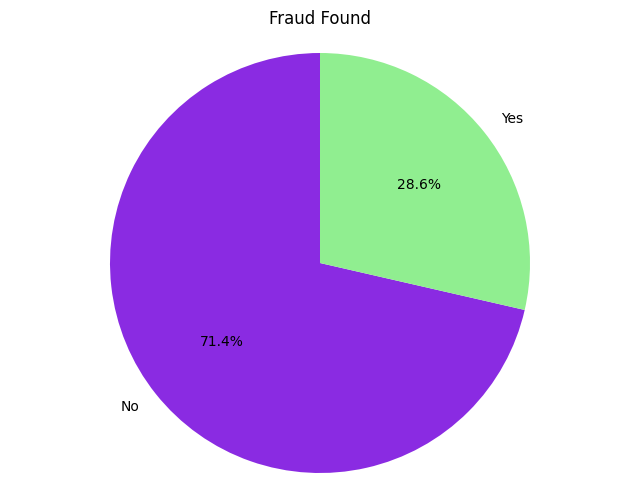

In [19]:
# Fraud Found - target: imbalanced data
fraud_counts = df['FraudFound_P'].value_counts()

labels = {0: 'No', 1: 'Yes'}

pie_labels = fraud_counts.index.map(lambda x: labels[x])
colors = ['blueviolet','lightgreen']

plt.figure(figsize=(8, 6))
plt.pie(fraud_counts, labels=pie_labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Fraud Found')
plt.axis('equal')


plt.show()

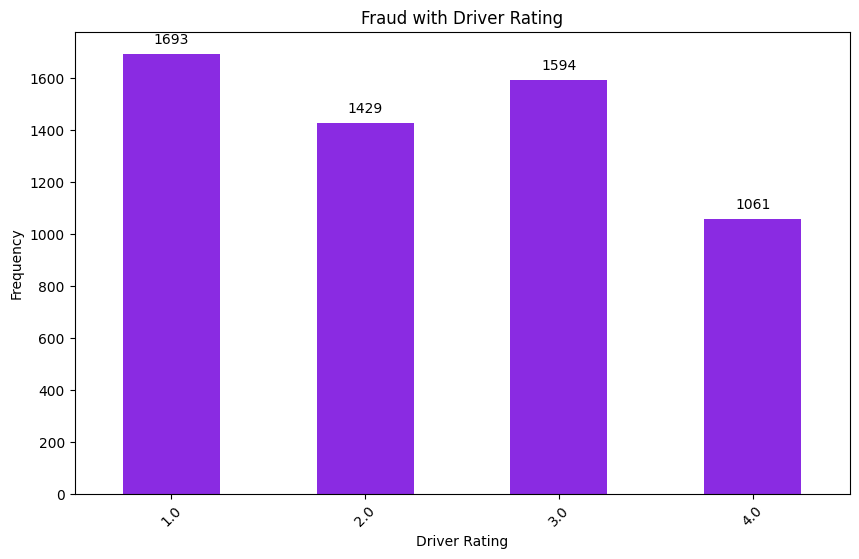

In [20]:
def plot_relation_fraud2(df,fraud_column,cause_column,Title):
    fraud_df = df[df[fraud_column] == 1]

    fraud_df = fraud_df.groupby(cause_column).size()
    expected_categories = [1,2,3,4]
    # fraud_df = fraud_df.reindex(expected_categories)


    plt.figure(figsize=(10, 6))
    bars = fraud_df.plot(kind='bar', color='blueviolet')

    plt.title('Fraud with ' + Title )
    plt.xlabel(Title)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)

    for p in bars.patches:
        bars.annotate(format(p.get_height(), 'd'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 10),
                        textcoords = 'offset points')
    plt.show()

plot_relation_fraud2(df,'FraudFound_P','DriverRating','Driver Rating')

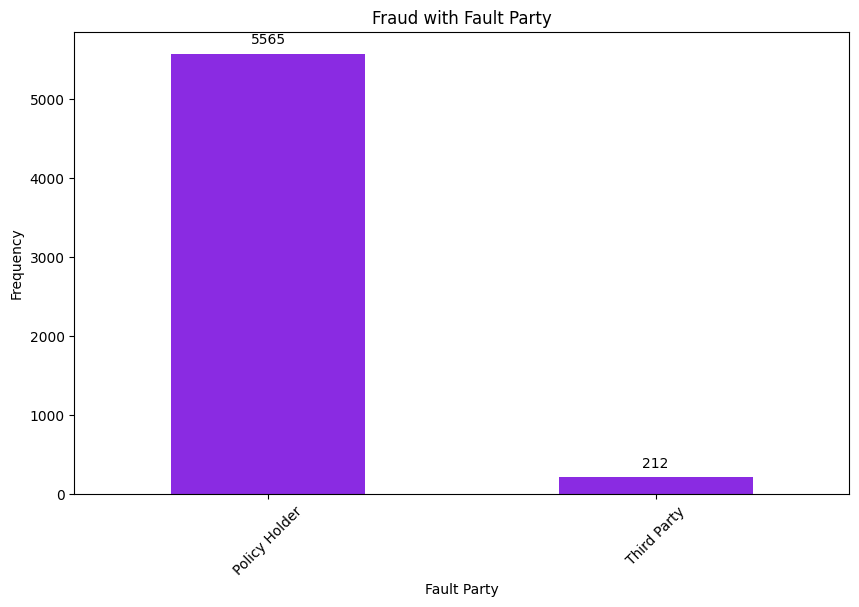

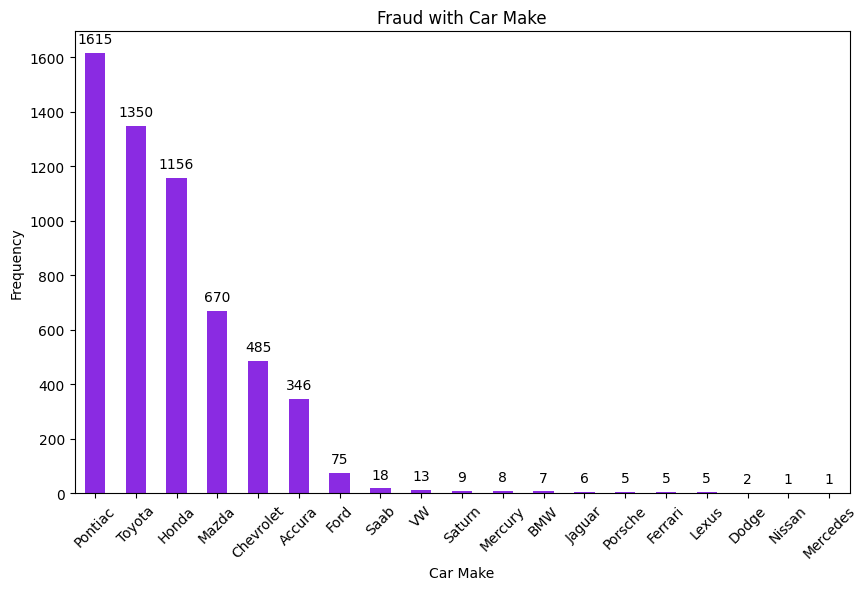

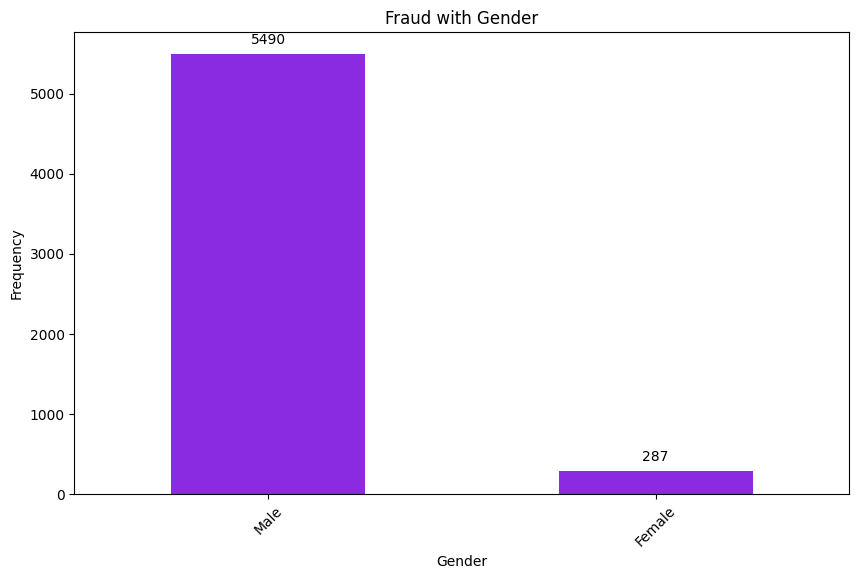

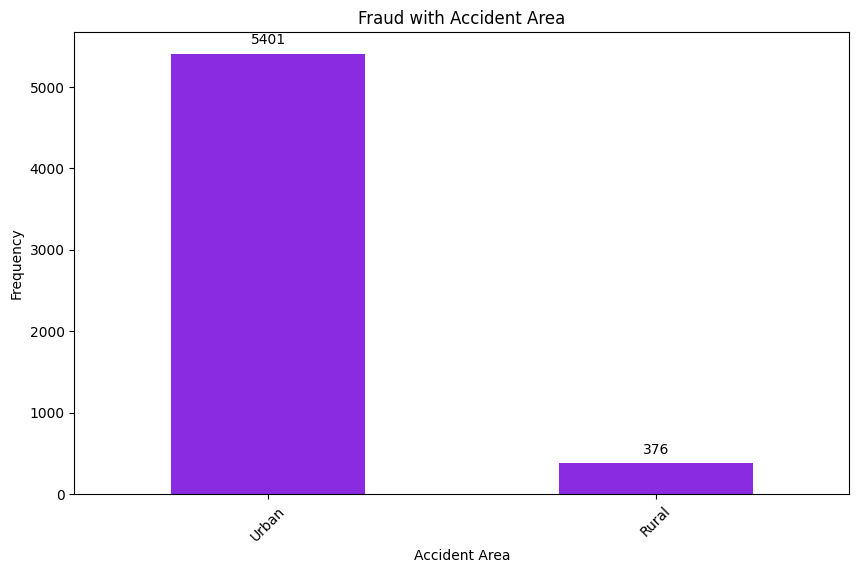

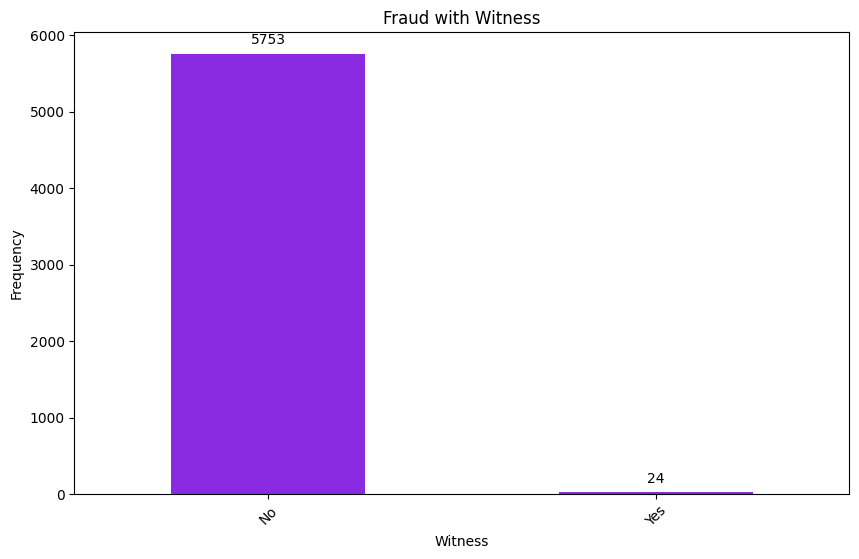

In [21]:
def plot_relation_fraud(df,fraud_column,cause_column,Title):
    fraud_df = df[df[fraud_column] == 1][cause_column].value_counts()

    plt.figure(figsize=(10, 6))
    bars = fraud_df.plot(kind='bar', color='blueviolet')

    plt.title('Fraud with ' + Title )
    plt.xlabel(Title)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)

    for p in bars.patches:
        bars.annotate(format(p.get_height(), 'd'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 10),
                        textcoords = 'offset points')
    plt.show()

plot_relation_fraud(df,'FraudFound_P','Fault','Fault Party')
plot_relation_fraud(df,'FraudFound_P','Make','Car Make')
plot_relation_fraud(df,'FraudFound_P','Sex','Gender')
plot_relation_fraud(df,'FraudFound_P','AccidentArea','Accident Area')
plot_relation_fraud(df,'FraudFound_P','WitnessPresent','Witness')

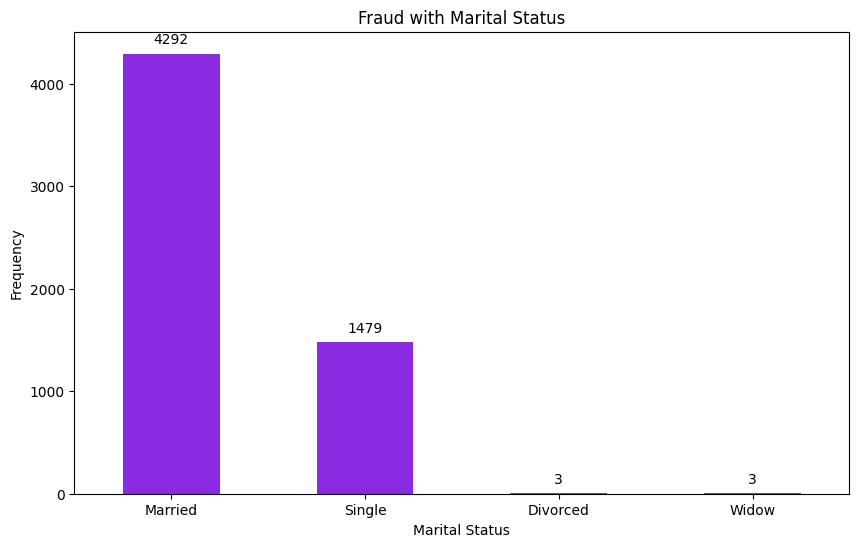

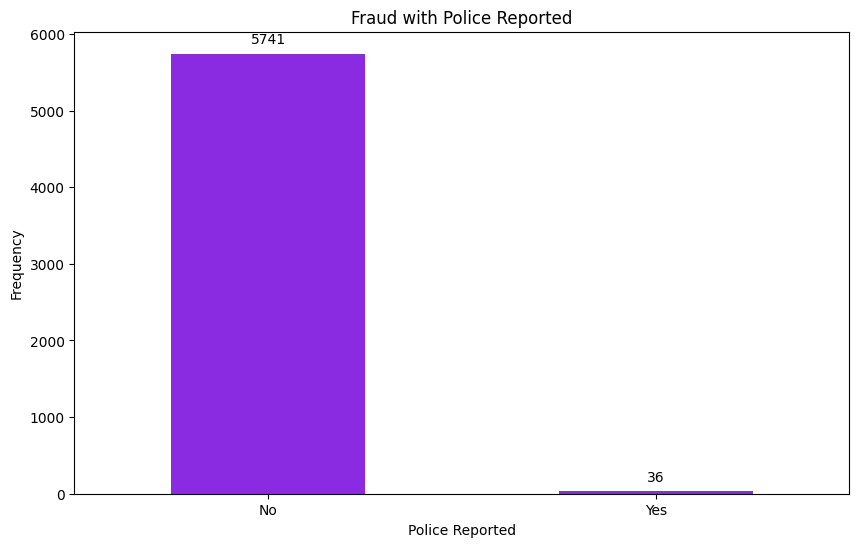

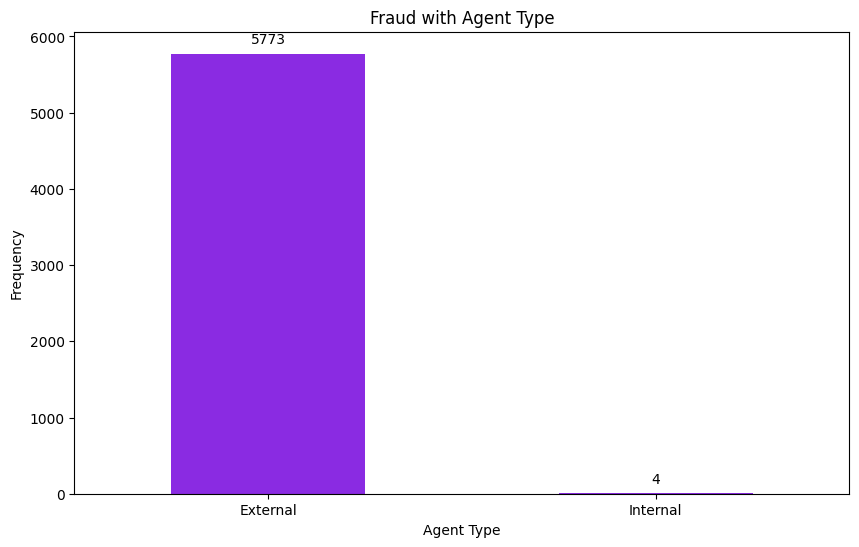

In [ ]:
plot_relation_fraud(df,'FraudFound_P','MaritalStatus','Marital Status')
plot_relation_fraud(df,'FraudFound_P','PoliceReportFiled','Police Reported')
plot_relation_fraud(df,'FraudFound_P','AgentType','Agent Type')

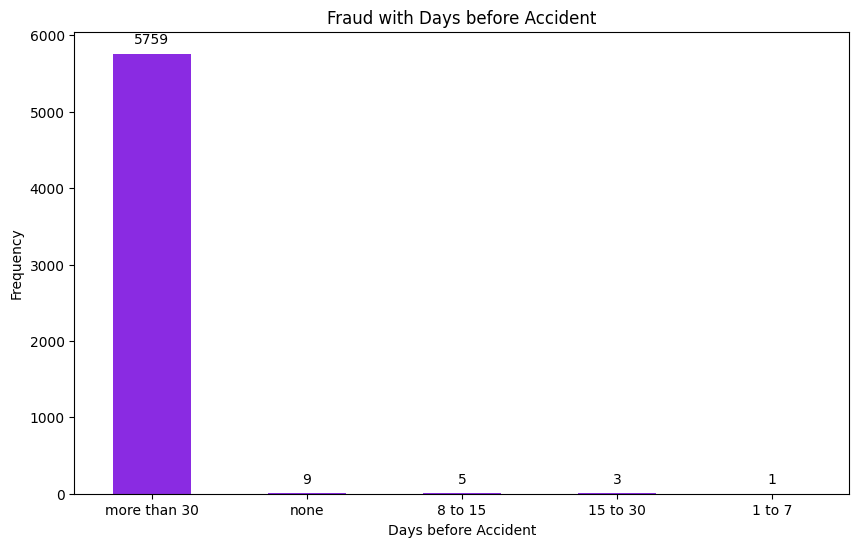

In [ ]:
plot_relation_fraud(df,'FraudFound_P','Days_Policy_Accident','Days before Accident')

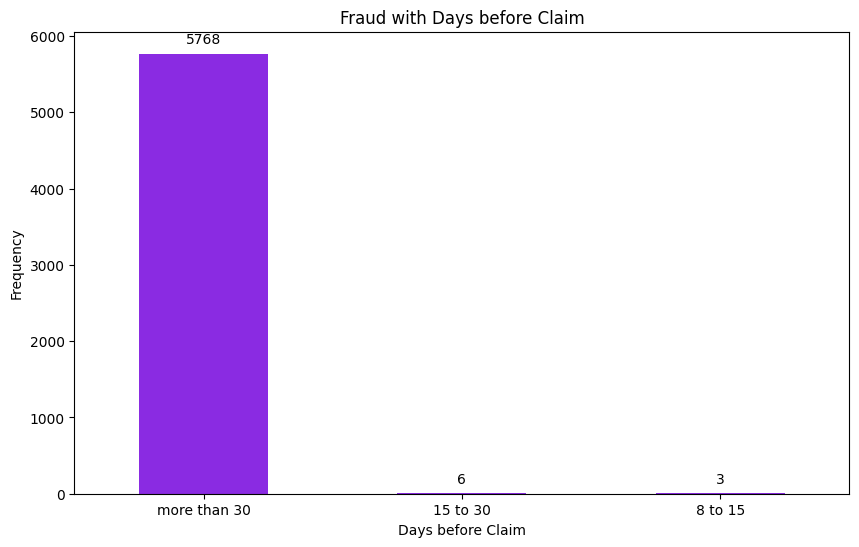

In [ ]:
plot_relation_fraud(df,'FraudFound_P','Days_Policy_Claim','Days before Claim')

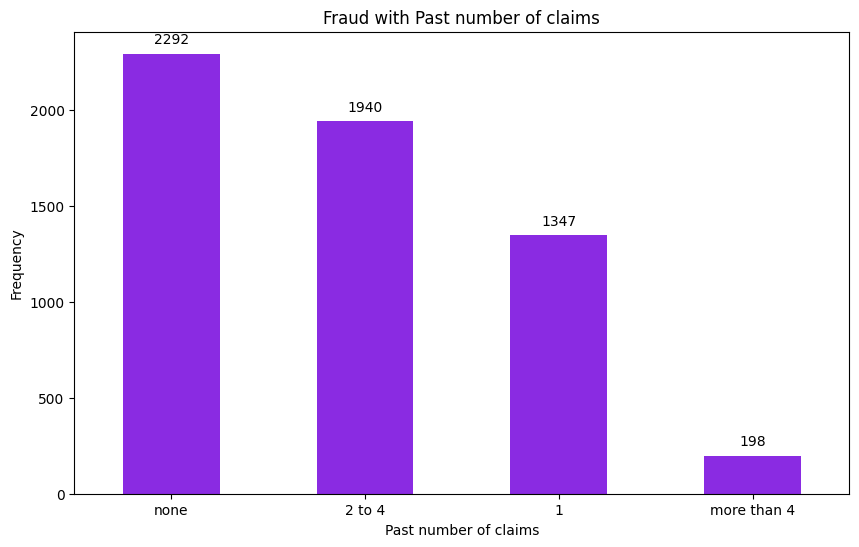

In [ ]:
plot_relation_fraud(df,'FraudFound_P','PastNumberOfClaims','Past number of claims')

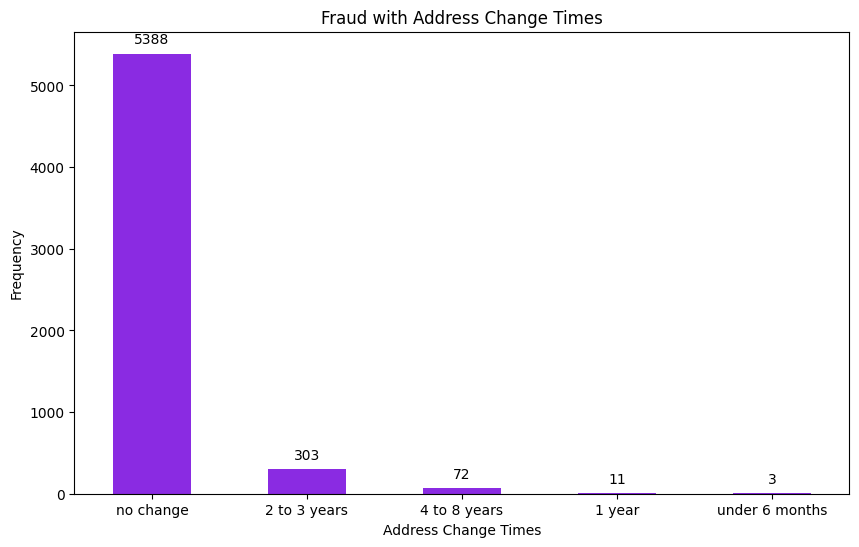

In [ ]:
plot_relation_fraud(df,'FraudFound_P','AddressChange_Claim','Address Change Times')

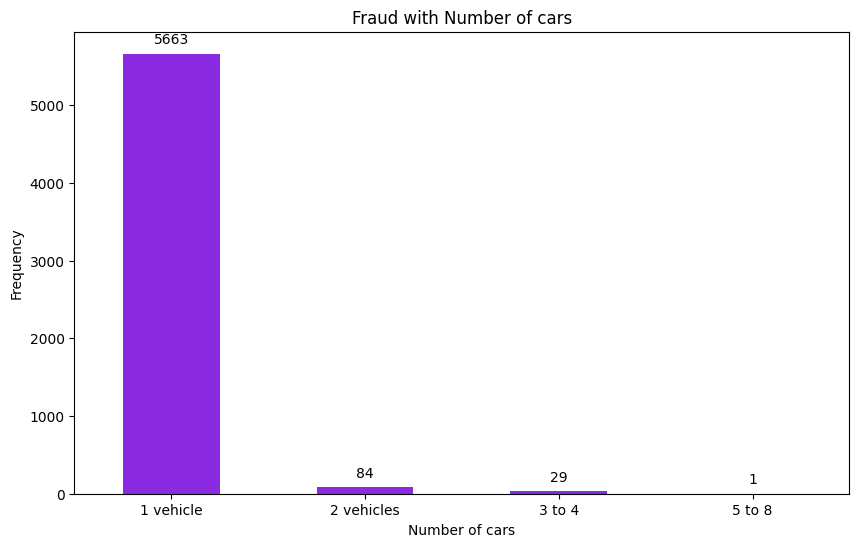

In [ ]:
plot_relation_fraud(df,'FraudFound_P','NumberOfCars','Number of cars')

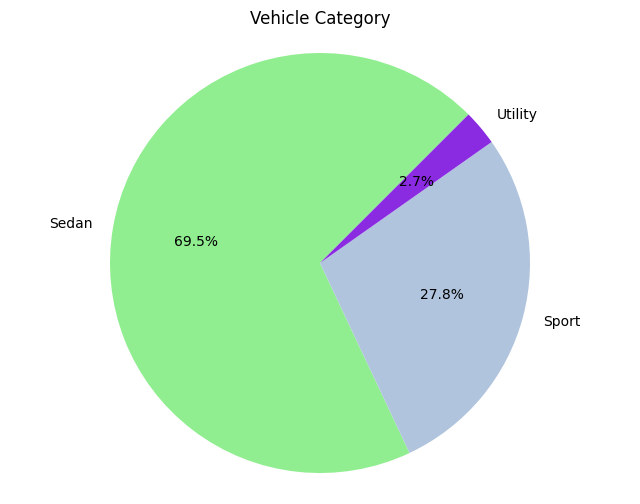

In [ ]:
def pie_3(column_to_pie,title):

    column_to_pie = df[column_to_pie].value_counts()

    colors = ['lightgreen', 'lightsteelblue','blueviolet']

    plt.figure(figsize=(8, 6))
    plt.pie(column_to_pie, labels=column_to_pie.index, autopct='%1.1f%%', startangle=45, colors=colors)
    plt.title(title)
    plt.axis('equal')
    plt.show()

pie_3('VehicleCategory','Vehicle Category')

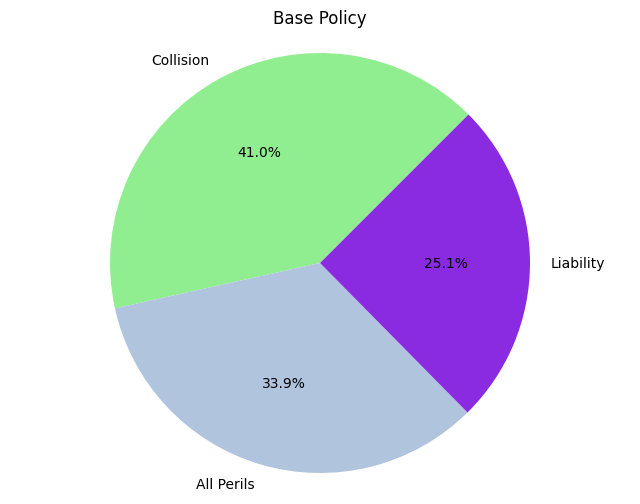

In [ ]:
pie_3('BasePolicy','Base Policy')

## Modelling - Label encoding to do the correlation test

In [ ]:
le = LabelEncoder()

categorical_columns = df.select_dtypes(include=['object']).columns

for column in categorical_columns:
    df[column] = le.fit_transform(df[column])

df.head(5)


,Month,Make,AccidentArea,MonthClaimed,Sex,MaritalStatus,Fault,VehicleCategory,VehiclePrice,Deductible,...,Days_Policy_Claim,PastNumberOfClaims,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,AddressChange_Claim,NumberOfCars,BasePolicy,FraudFound_P
0,7,6,1,9,1,2,0,0,96494,400.0,...,2,3,0,0,0,0,3,0,0,1.0
1,7,6,0,1,1,1,0,1,89807,400.0,...,2,3,1,0,0,0,3,0,1,1.0
2,7,6,1,8,1,1,0,0,25517,400.0,...,2,3,1,0,0,0,3,0,1,1.0
3,11,6,1,1,1,2,0,1,70903,400.0,...,2,3,1,0,0,0,3,0,1,1.0
4,11,17,1,1,1,1,0,0,28016,400.0,...,2,0,1,0,0,0,3,0,1,1.0


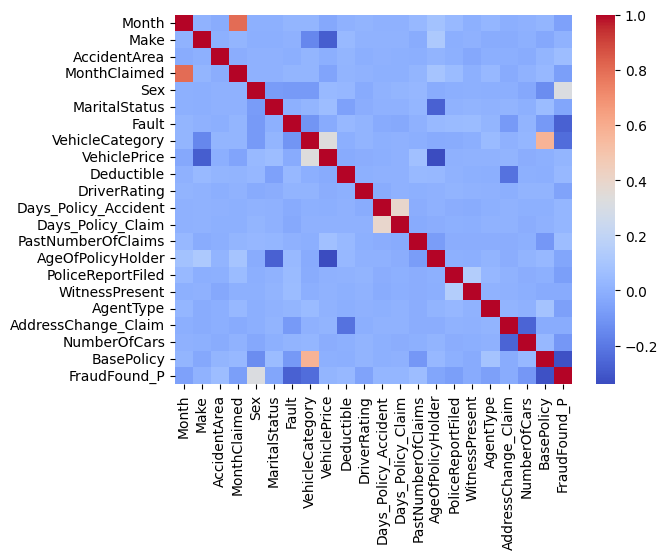

In [ ]:
sns.heatmap(df.corr(),annot=False,cmap='coolwarm')
figsize=(20, 10)

### Correlation pair:
- month claimed - month (month claimed)
- vehicle category - make (vehicle category)
- vehicle price - make (vehicle price)
- age of policy holder - marital status (marital status)
- Base policy - vehicle category (vehicle category)
- age of policy holder - vehicle price (vehicle price)
- addresschange claim - deductible (both)
- number of cars - address change claim(both)

Fraud found -> Fault, vehicle category, base policy


In [ ]:
df = df.drop(columns = ['Month','Make','AgeOfPolicyHolder','BasePolicy'])

## New dataset

In [ ]:
df.head(5)

,AccidentArea,MonthClaimed,Sex,MaritalStatus,Fault,VehicleCategory,VehiclePrice,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,PoliceReportFiled,WitnessPresent,AgentType,AddressChange_Claim,NumberOfCars,FraudFound_P
0,1,9,1,2,0,0,96494,400.0,1.0,3,2,3,0,0,0,3,0,1.0
1,0,1,1,1,0,1,89807,400.0,4.0,3,2,3,0,0,0,3,0,1.0
2,1,8,1,1,0,0,25517,400.0,2.0,3,2,3,0,0,0,3,0,1.0
3,1,1,1,2,0,1,70903,400.0,3.0,3,2,3,0,0,0,3,0,1.0
4,1,1,1,1,0,0,28016,400.0,2.0,3,2,0,0,0,0,3,0,1.0


In [ ]:
for column in df.columns:
    unique_values = df[column].unique()
    print(f"'{column}' -  {unique_values}")

'AccidentArea' -  [1 0]
'MonthClaimed' -  [ 9  1  8 12  5 11  2  4  3 10  7  6]
'Sex' -  [1 0]
'MaritalStatus' -  [2 1 0 3]
'Fault' -  [0 1]
'VehicleCategory' -  [0 1 2]
'VehiclePrice' -  [96494 89807 25517 ... 37556 34145 14796]
'Deductible' -  [400. 500. 700. 300. 408. 379. 391. 354. 321. 380. 310. 333. 311. 320.
 322. 324. 377. 355.]
'DriverRating' -  [1. 4. 2. 3.]
'Days_Policy_Accident' -  [3 4 0 2 1]
'Days_Policy_Claim' -  [2 1 0 3]
'PastNumberOfClaims' -  [3 0 2 1]
'PoliceReportFiled' -  [0 1]
'WitnessPresent' -  [0 1]
'AgentType' -  [0 1]
'AddressChange_Claim' -  [3 4 2 1 0]
'NumberOfCars' -  [0 1 2 3 4]
'FraudFound_P' -  [1. 0.]


## Split and save the Dataset: Train, Test, Validation

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_test_df = train_test_split(df, test_size=0.4, random_state=42)

test_df, val_df = train_test_split(temp_test_df, test_size=0.5, random_state=42)



In [ ]:
# Display the shape of train, valid and test sets.
print(train_df.shape)
print(test_df.shape)
print(val_df.shape)

(12124, 18)
(4041, 18)
(4042, 18)


In [ ]:
# Save the data as separate csv files.
train_df.to_csv('train.csv', index=False)
val_df.to_csv('valid.csv', index=False)
test_df.to_csv('test.csv', index=False)

### Assign X and y for later numeric representation and model training

In [ ]:
# Load the train.csv
train = pd.read_csv("train.csv")

# Assign X train and y train
X_train = train.drop('FraudFound_P', axis=1)
y_train = train['FraudFound_P']

#Display the shape of X_train.
X_train.shape

(12124, 17)

In [ ]:
X_train.head(5)

,AccidentArea,MonthClaimed,Sex,MaritalStatus,Fault,VehicleCategory,VehiclePrice,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,PoliceReportFiled,WitnessPresent,AgentType,AddressChange_Claim,NumberOfCars
0,1,4,0,1,0,1,34500,400.0,1.0,3,2,1,0,0,0,3,0
1,1,5,1,1,0,0,28411,400.0,3.0,3,2,0,0,0,0,3,0
2,1,1,1,2,1,0,23471,400.0,1.0,3,2,3,0,0,0,3,0
3,1,4,0,2,1,1,22333,400.0,4.0,3,2,1,0,0,0,3,0
4,1,9,0,1,1,1,28725,400.0,1.0,3,2,2,0,0,0,3,0


In [ ]:
y_train.shape

(12124,)

**Function to encoding**

In [ ]:
# columns_to_onehot = ['Make',AccidentArea', 'Sex', 'MaritalStatus', 'Fault', 'VehicleCategory', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'BasePolicy']
# columns_to_labelencode = ['Days_Policy_Accident', 'Days_Policy_Claim', 'AgeOfPolicyHolder', 'PastNumberOfClaims', 'AddressChange_Claim', 'NumberOfCars']

# def preprocess_data(X, columns_to_onehot, columns_to_labelencode):
#     X_onehot = pd.get_dummies(X[columns_to_onehot])
#     X_onehot = X_onehot * 1
#     le = LabelEncoder()
#     for column in columns_to_labelencode:
#         X[column] = le.fit_transform(X[column])
#     X_modified = X.drop(columns_to_onehot, axis=1)
#     X = pd.concat([X_modified, X_onehot], axis=1)
#     return X

Logistic Regression

In [ ]:
from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()

In [ ]:
Scaler_x = Scaler.fit(X_train)

In [ ]:
X_train_scaler = Scaler_x.transform(X_train)

In [ ]:
# from sklearn.linear_model import LogisticRegression
# lr = LogisticRegression(penalty='l2', C=10, solver='lbfgs', max_iter=100, random_state=42)

In [ ]:
# lr.fit(X_train_scaler, y_train)

In [ ]:
# Load the val.csv
val = pd.read_csv("valid.csv")

# Assign X val and y val
X_val = val.drop('FraudFound_P', axis=1)
y_val = val['FraudFound_P']

#Display the shape of X_train.
X_val.shape

(4042, 17)

In [ ]:
X_val_scaler = Scaler_x.transform(X_val)

In [ ]:
# y_pred = lr.predict(X_val_scaler)

In [ ]:
# y_pred.shape

In [ ]:
# y_val.shape

In [ ]:
# from sklearn.metrics import confusion_matrix
# from sklearn.metrics import confusion_matrix, classification_report
# from mlxtend.plotting import plot_confusion_matrix
# print(classification_report(y_val, y_pred))
# cm1 = confusion_matrix(y_val,y_pred)
# plot_confusion_matrix(conf_mat=cm1,show_absolute=True,
#                                 show_normed=True,
#                                 colorbar=True,
#                                 )
# plt.show()

In [ ]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import classification_report

# param_grid = {
#     'penalty': ['l1', 'l2', 'elasticnet','none'],
#     'C': [0.01, 0.1, 1, 10,100],
#     'solver': ['liblinear', 'lbfgs', 'saga'],
#     'max_iter': [100, 200, 300]
# }


# log_reg = LogisticRegression()

# grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='accuracy', verbose=1)


# grid_search.fit(X_train_scaler, y_train)

# print("tuned hpyerparameters :(best parameters) ",grid_search.best_params_)
# print("accuracy :",grid_search.best_score_)

Fitting 5 folds for each of 180 candidates, totalling 900 fits


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1173: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1173: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1173: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour

tuned hpyerparameters :(best parameters)  {'C': 0.01, 'max_iter': 100, 'penalty': 'l1', 'solver': 'saga'}
accuracy : 0.7890964580994182


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:952: UserWarning: One or more of the test scores are non-finite: [0.788189          nan 0.78909646 0.78653945 0.78406468 0.78406468
        nan        nan        nan        nan 0.78686935 0.78686935
 0.788189          nan 0.78909646 0.78653945 0.78406468 0.78406468
        nan        nan        nan        nan 0.78686935 0.78686935
 0.788189          nan 0.78909646 0.78653945 0.78406468 0.78406468
        nan        nan        nan        nan 0.78686935 0.78686935
 0.78620955        nan 0.7867044  0.78670433 0.78695186 0.78695186
        nan        nan        nan        nan 0.78686935 0.78686935
 0.78620955        nan 0.7867044  0.78670433 0.78695186 0.78695186
        nan        nan        nan        nan 0.78686935 0.78686935
 0.78620955        nan 0.7867044  0.78670433 0.78695186 0.78695186
        nan        nan        nan        nan 0.78686935 0.78686935
 0.78678687        nan 0.7867044  0.78695182 0.78686935 

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(penalty='l1', C=0.01, solver='saga', max_iter=100, random_state=42)

In [ ]:
lr.fit(X_train_scaler, y_train)

LogisticRegression(C=0.01, penalty='l1', random_state=42, solver='saga')

              precision    recall  f1-score   support

         0.0       0.85      0.83      0.84      2881
         1.0       0.61      0.65      0.63      1161

    accuracy                           0.78      4042
   macro avg       0.73      0.74      0.73      4042
weighted avg       0.78      0.78      0.78      4042



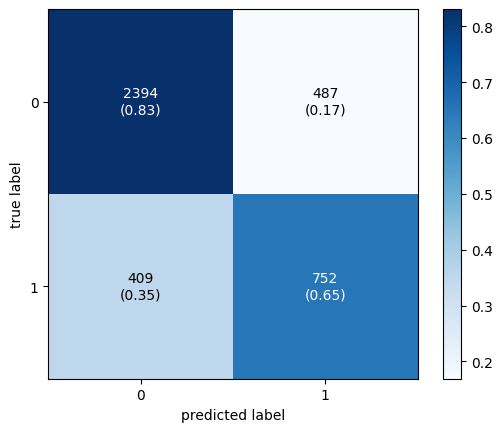

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from mlxtend.plotting import plot_confusion_matrix
y_pred = lr.predict(X_val_scaler)


print(classification_report(y_val, y_pred))
cm1 = confusion_matrix(y_val,y_pred)
plot_confusion_matrix(conf_mat=cm1,show_absolute=True,
                                show_normed=True,
                                colorbar=True,
                                )
plt.show()

In [ ]:
y_scores = lr.predict_proba(X_val_scaler)[:, 1]

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_val, y_scores)


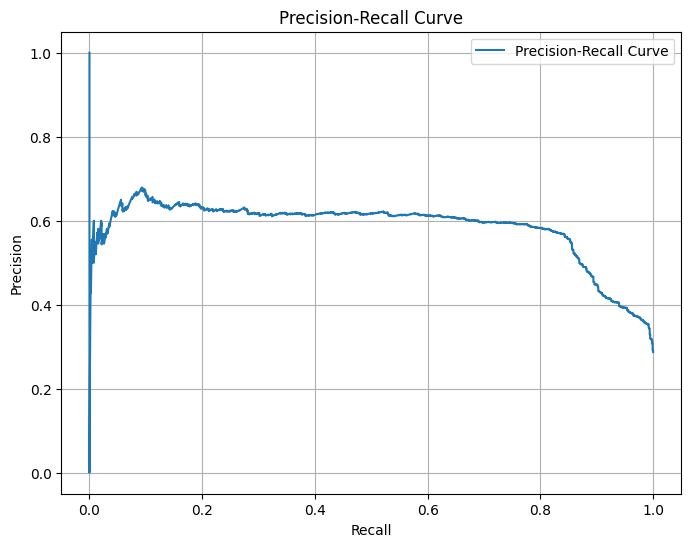

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()


Support Vector Machine (SVM), Random-Forest (RF), Decision-Tree (DT), Adaboost, K-Nearest Neighbor (KNN), Linear Regression (LR), Naïve Bayes (NB), and Multi-Layer Perceptron (MLP)

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

In [ ]:
ros = RandomUnderSampler(random_state=99)
X_undersam, y_undersam = ros.fit_resample(X_train_scaler, y_train)

In [ ]:
# sns.countplot(x=y_undersam)
# plt.title("Fraud Vs Not-Fraud \n with Unsersampling")

In [ ]:
lr.fit(X_undersam, y_undersam)

LogisticRegression(C=0.01, penalty='l1', random_state=42, solver='saga')

              precision    recall  f1-score   support

         0.0       0.92      0.73      0.82      2881
         1.0       0.56      0.85      0.68      1161

    accuracy                           0.76      4042
   macro avg       0.74      0.79      0.75      4042
weighted avg       0.82      0.76      0.78      4042



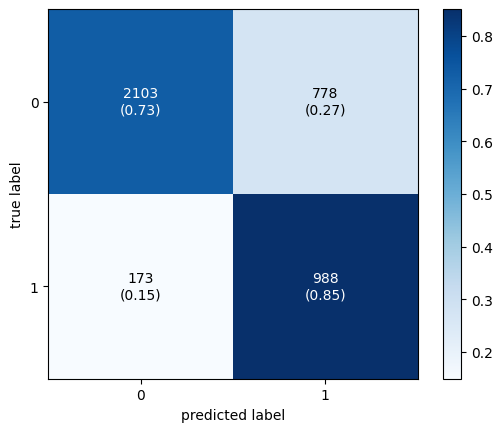

In [ ]:
y_pred_lr_under = lr.predict(X_val_scaler)



print(classification_report(y_val, y_pred_lr_under))
cm1 = confusion_matrix(y_val,y_pred_lr_under )
plot_confusion_matrix(conf_mat=cm1,show_absolute=True,
                                show_normed=True,
                                colorbar=True,
                                )
plt.show()

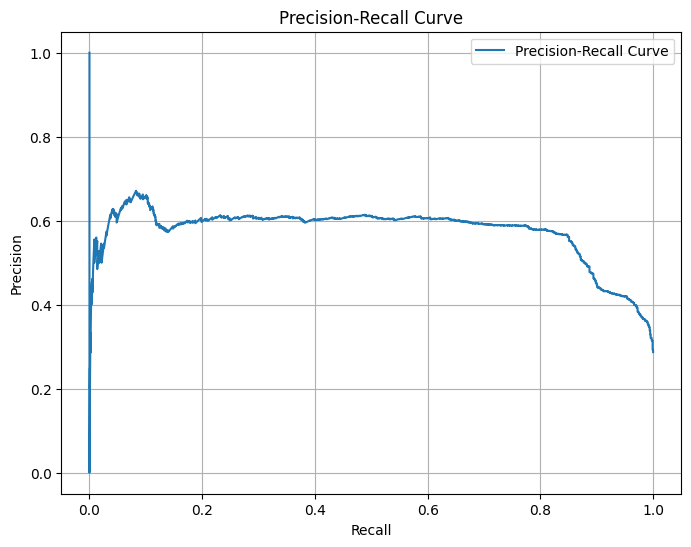

In [ ]:
y_scores = lr.predict_proba(X_val_scaler)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_scores)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

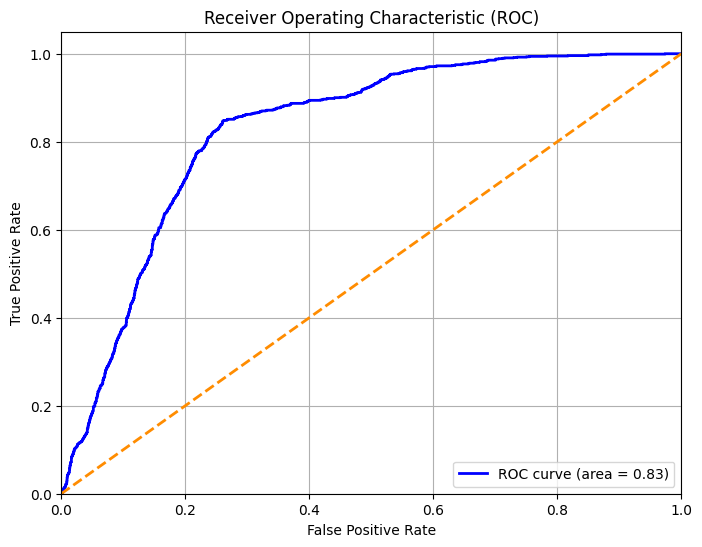

In [ ]:
fpr, tpr, thresholds = roc_curve(y_val, y_scores)

auc_score = roc_auc_score(y_val, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % auc_score)
plt.plot([0, 1], [0, 1], color='darkorange', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
from imblearn.over_sampling import RandomOverSampler

In [ ]:
ros = RandomOverSampler(random_state=99)
X_oversam, y_oversam = ros.fit_resample(X_train_scaler, y_train)

In [ ]:
lr.fit(X_oversam, y_oversam)


LogisticRegression(C=0.01, penalty='l1', random_state=42, solver='saga')

In [ ]:
y_pred_lr_over = lr.predict(X_val_scaler)


              precision    recall  f1-score   support

         0.0       0.92      0.73      0.82      2881
         1.0       0.56      0.85      0.67      1161

    accuracy                           0.77      4042
   macro avg       0.74      0.79      0.75      4042
weighted avg       0.82      0.77      0.78      4042



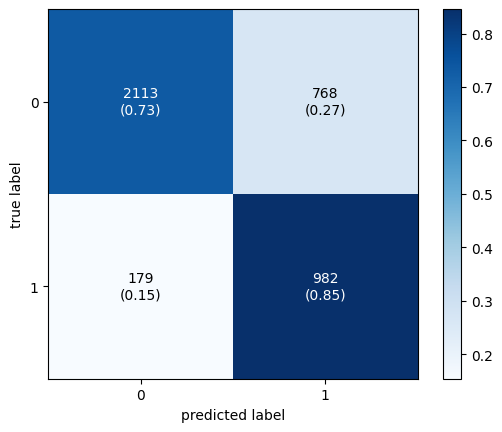

In [ ]:
print(classification_report(y_val, y_pred_lr_over))
cm1 = confusion_matrix(y_val,y_pred_lr_over)
plot_confusion_matrix(conf_mat=cm1,show_absolute=True,
                                show_normed=True,
                                colorbar=True,
                                )
plt.show()

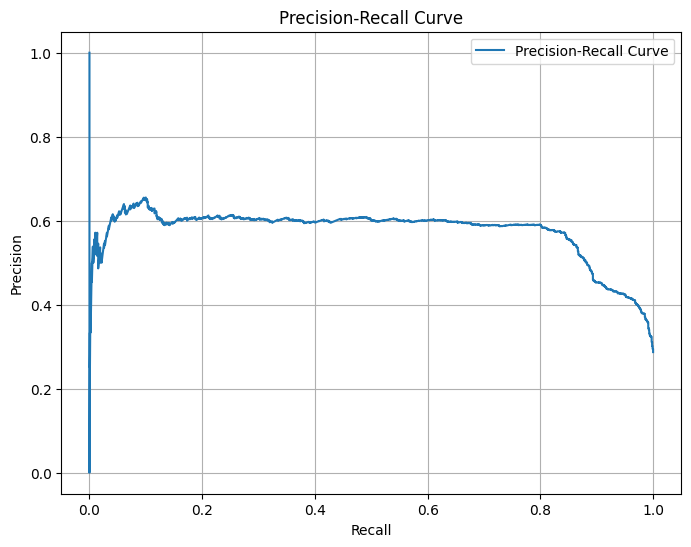

In [ ]:
y_scores = lr.predict_proba(X_val_scaler)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_scores)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy='minority',random_state=99,k_neighbors=5)

In [ ]:
X_smote, y_smote = smote.fit_resample(X_train_scaler, y_train)


In [ ]:
lr.fit(X_smote, y_smote)


LogisticRegression(C=0.01, penalty='l1', random_state=42, solver='saga')

              precision    recall  f1-score   support

         0.0       0.92      0.74      0.82      2881
         1.0       0.57      0.84      0.68      1161

    accuracy                           0.77      4042
   macro avg       0.74      0.79      0.75      4042
weighted avg       0.82      0.77      0.78      4042



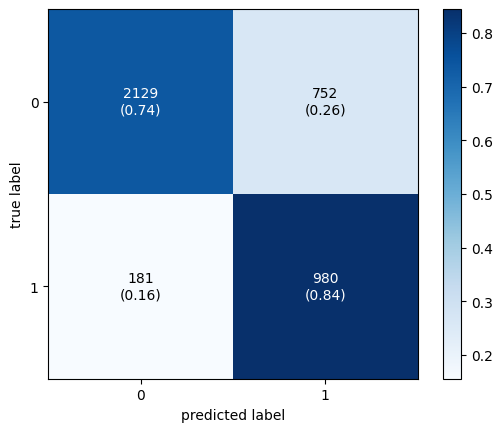

In [ ]:
y_pred_lr_smote = lr.predict(X_val_scaler)
print(classification_report(y_val, y_pred_lr_smote))
cm1 = confusion_matrix(y_val,y_pred_lr_smote)
plot_confusion_matrix(conf_mat=cm1,show_absolute=True,
                                show_normed=True,
                                colorbar=True,
                                )
plt.show()

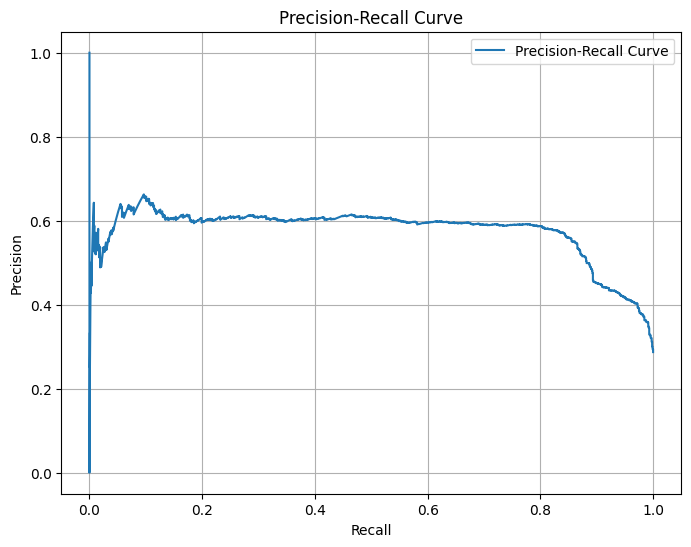

In [ ]:
y_scores = lr.predict_proba(X_val_scaler)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_scores)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

## Logistic regression(under sampling): 92%-85%(173)

(LogisticRegression(penalty='l1', C=0.01, solver='saga', max_iter=100, random_state=42))

## Random Forest

In [ ]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import GridSearchCV


# rf = RandomForestClassifier()

# param_grid = {
#     'n_estimators': [100, 200],
#     'max_features': ['sqrt', 'log2'],
#     'max_depth': [None, 10, 20],
#     'min_samples_split': [2, 5],
#     'min_samples_leaf': [1, 2]
# }

# grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy')


# grid_search.fit(X_train_scaler, y_train)

# # best parameter
# print("best parameter：", grid_search.best_params_)


best parameter： {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(max_depth=20, max_features='sqrt', min_samples_leaf=1, min_samples_split=5, n_estimators=200)

In [ ]:
rf.fit(X_train_scaler, y_train)

RandomForestClassifier(max_depth=20, min_samples_split=5, n_estimators=200)

In [ ]:
y_pred_rf = rf.predict(X_val_scaler)

              precision    recall  f1-score   support

         0.0       0.92      0.89      0.90      2881
         1.0       0.74      0.80      0.77      1161

    accuracy                           0.86      4042
   macro avg       0.83      0.84      0.84      4042
weighted avg       0.87      0.86      0.86      4042



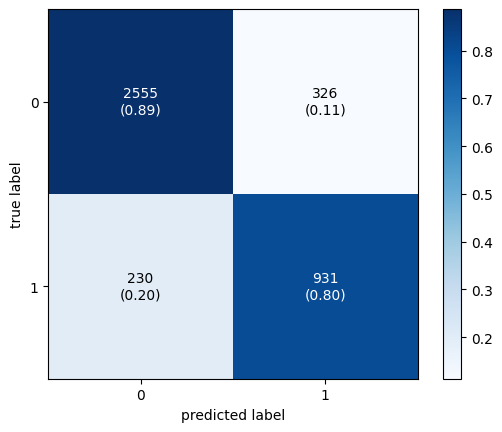

In [ ]:
print(classification_report(y_val, y_pred_rf))
cm1 = confusion_matrix(y_val,y_pred_rf)
plot_confusion_matrix(conf_mat=cm1,show_absolute=True,
                                show_normed=True,
                                colorbar=True,
                                )
plt.show()

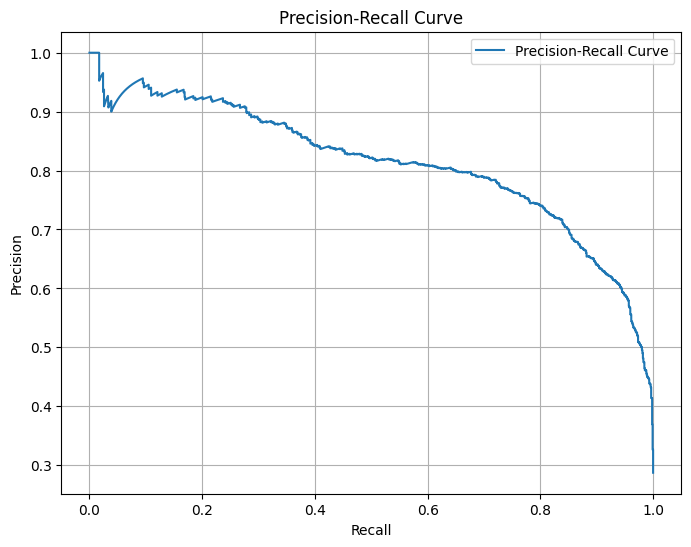

In [ ]:
y_scores = rf.predict_proba(X_val_scaler)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_scores)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

              precision    recall  f1-score   support

         0.0       0.95      0.81      0.87      2881
         1.0       0.65      0.90      0.76      1161

    accuracy                           0.83      4042
   macro avg       0.80      0.85      0.82      4042
weighted avg       0.87      0.83      0.84      4042



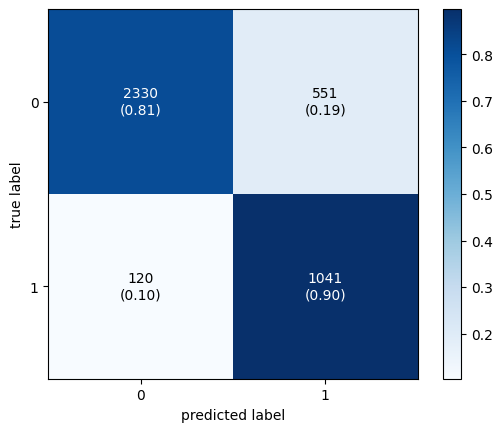

In [ ]:
rf.fit(X_undersam, y_undersam)
y_pred_rf_under = rf.predict(X_val_scaler)
print(classification_report(y_val, y_pred_rf_under))
cm1 = confusion_matrix(y_val,y_pred_rf_under)
plot_confusion_matrix(conf_mat=cm1,show_absolute=True,
                                show_normed=True,
                                colorbar=True,
                                )
plt.show()

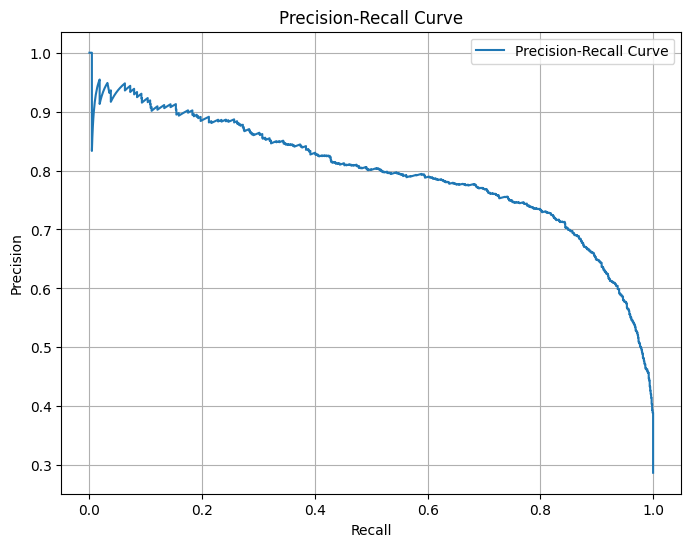

In [ ]:
y_scores = rf.predict_proba(X_val_scaler)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_scores)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

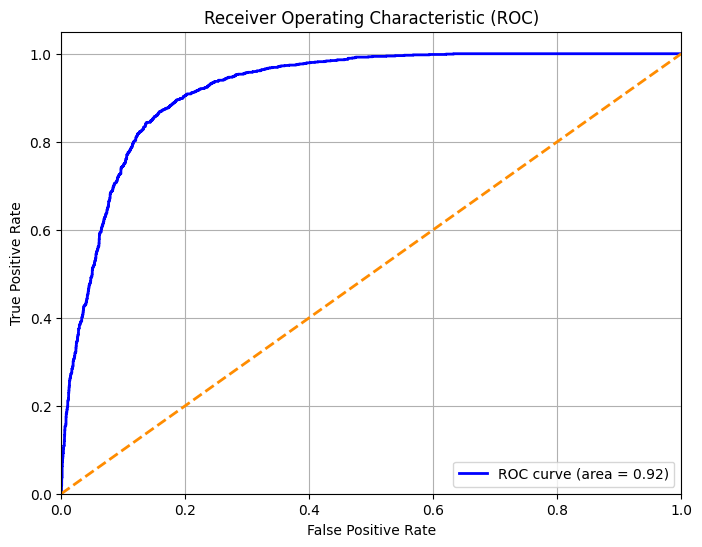

In [ ]:
fpr, tpr, thresholds = roc_curve(y_val, y_scores)

auc_score = roc_auc_score(y_val, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % auc_score)
plt.plot([0, 1], [0, 1], color='darkorange', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


              precision    recall  f1-score   support

         0.0       0.94      0.84      0.89      2881
         1.0       0.69      0.87      0.77      1161

    accuracy                           0.85      4042
   macro avg       0.81      0.85      0.83      4042
weighted avg       0.87      0.85      0.85      4042



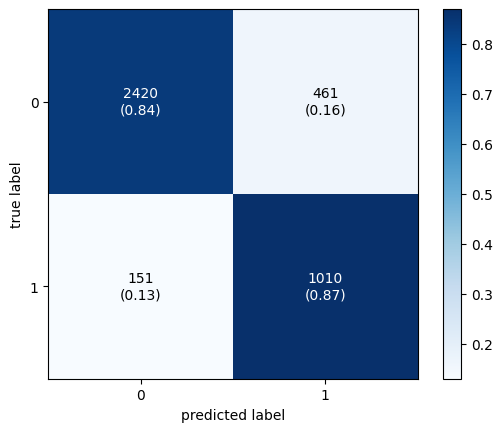

In [ ]:
rf.fit(X_oversam, y_oversam)
y_pred_rf_over = rf.predict(X_val_scaler)
print(classification_report(y_val, y_pred_rf_over))
cm1 = confusion_matrix(y_val,y_pred_rf_over)
plot_confusion_matrix(conf_mat=cm1,show_absolute=True,
                                show_normed=True,
                                colorbar=True,
                                )
plt.show()

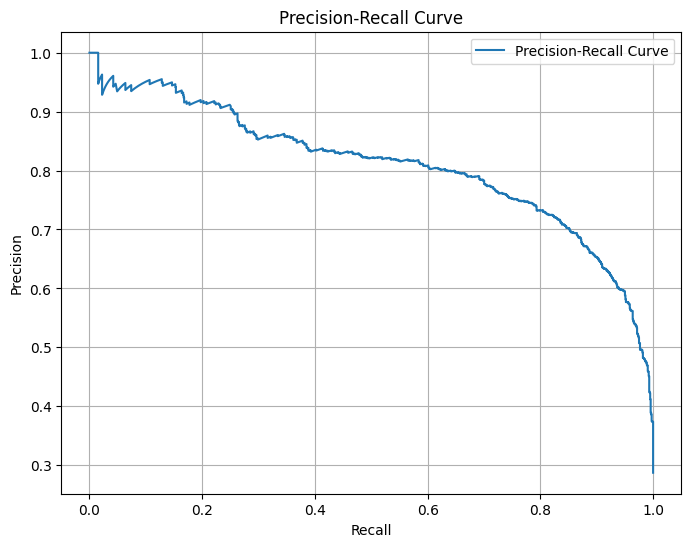

In [ ]:
y_scores = rf.predict_proba(X_val_scaler)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_scores)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

              precision    recall  f1-score   support

         0.0       0.93      0.84      0.89      2881
         1.0       0.69      0.85      0.76      1161

    accuracy                           0.85      4042
   macro avg       0.81      0.85      0.82      4042
weighted avg       0.86      0.85      0.85      4042



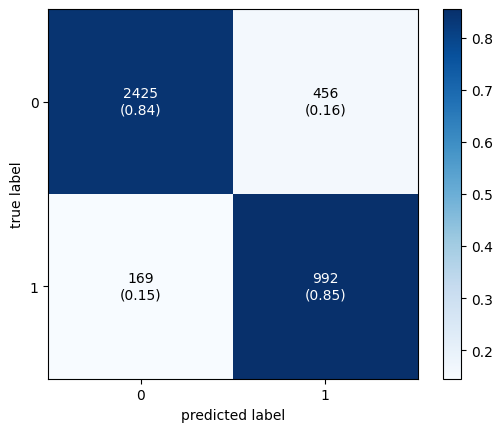

In [ ]:
rf.fit(X_smote, y_smote)
y_pred_rf_smote = rf.predict(X_val_scaler)
print(classification_report(y_val, y_pred_rf_smote))
cm1 = confusion_matrix(y_val,y_pred_rf_smote)
plot_confusion_matrix(conf_mat=cm1,show_absolute=True,
                                show_normed=True,
                                colorbar=True,
                                )
plt.show()

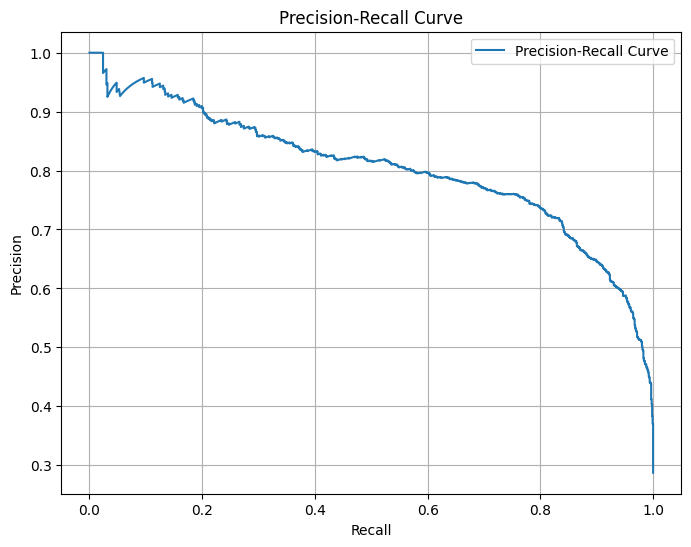

In [ ]:
y_scores = rf.predict_proba(X_val_scaler)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_scores)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# neighbours = np.arange(1,25)
# train_accuracy =np.empty(len(neighbours))
# val_accuracy = np.empty(len(neighbours))

# for i,k in enumerate(neighbours):
#     #Setup a knn classifier with k neighbors
#     knn=KNeighborsClassifier(n_neighbors=k,algorithm="kd_tree",n_jobs=-1)

#     #Fit the model
#     knn.fit(X_train_scaler,y_train)

#     #Compute accuracy on the training set
#     train_accuracy[i] = knn.score(X_train_scaler, y_train)
#     #Compute accuracy on the test set
#     val_accuracy[i] = knn.score(X_val_scaler, y_val)

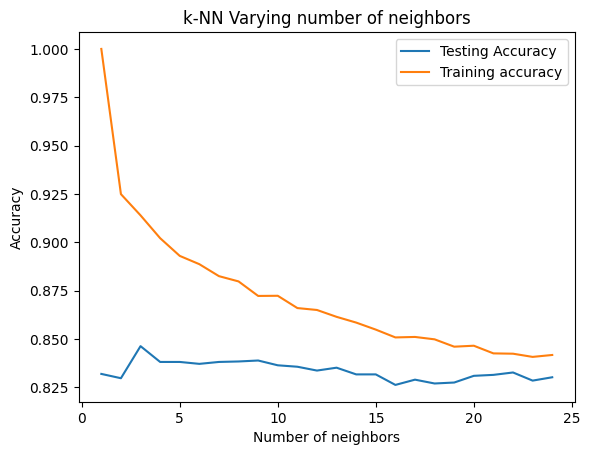

In [ ]:
# #Generate plot
# plt.title('k-NN Varying number of neighbors')
# plt.plot(neighbours, val_accuracy, label='Testing Accuracy')
# plt.plot(neighbours, train_accuracy, label='Training accuracy')
# plt.legend()
# plt.xlabel('Number of neighbors')
# plt.ylabel('Accuracy')
# plt.show()

In [ ]:
# idx = np.where(val_accuracy == max(val_accuracy))
# x = neighbours[idx]
# x

array([3])

In [ ]:
# from sklearn.neighbors import KNeighborsClassifier

# knn = KNeighborsClassifier()

# param_grid = {
#     'n_neighbors': range(1, 20),
#     'weights': ['uniform', 'distance'],
#     'metric': ['euclidean', 'manhattan', 'minkowski']
# }


# grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')


# grid_search.fit(X_train_scaler, y_train)


# print("best parameter：", grid_search.best_params_)
# print("score：", grid_search.best_score_)

best parameter： {'metric': 'manhattan', 'n_neighbors': 12, 'weights': 'distance'}
score： 0.8469154503079175


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(metric='manhattan', n_neighbors=12, weights='distance')


In [ ]:
knn.fit(X_train_scaler, y_train)

KNeighborsClassifier(metric='manhattan', n_neighbors=12, weights='distance')

In [ ]:
y_pred_knn = knn.predict(X_val_scaler)

              precision    recall  f1-score   support

         0.0       0.90      0.88      0.89      2881
         1.0       0.72      0.77      0.74      1161

    accuracy                           0.85      4042
   macro avg       0.81      0.82      0.82      4042
weighted avg       0.85      0.85      0.85      4042



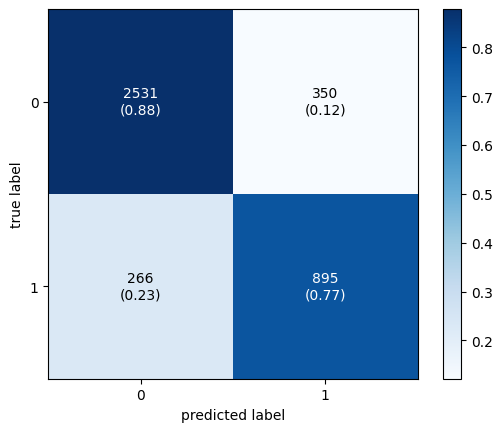

In [ ]:
print(classification_report(y_val, y_pred_knn))
cm1 = confusion_matrix(y_val,y_pred_knn)
plot_confusion_matrix(conf_mat=cm1,show_absolute=True,
                                show_normed=True,
                                colorbar=True,
                                )
plt.show()

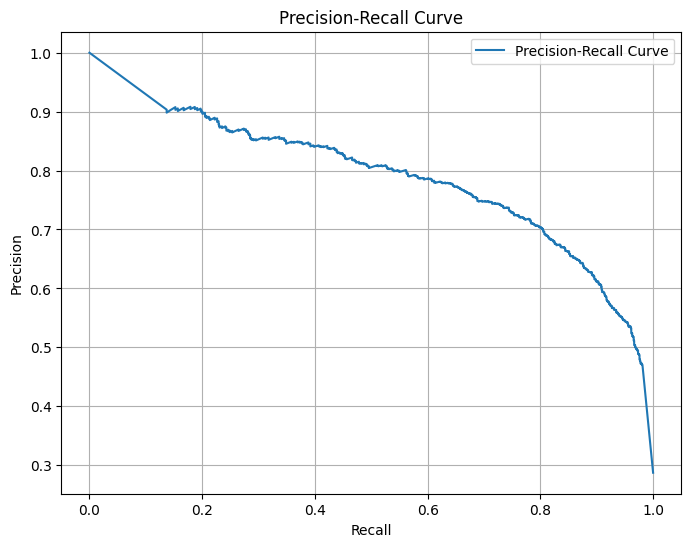

In [ ]:
y_scores = knn.predict_proba(X_val_scaler)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_scores)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

              precision    recall  f1-score   support

         0.0       0.95      0.81      0.87      2881
         1.0       0.65      0.90      0.76      1161

    accuracy                           0.83      4042
   macro avg       0.80      0.85      0.82      4042
weighted avg       0.87      0.83      0.84      4042



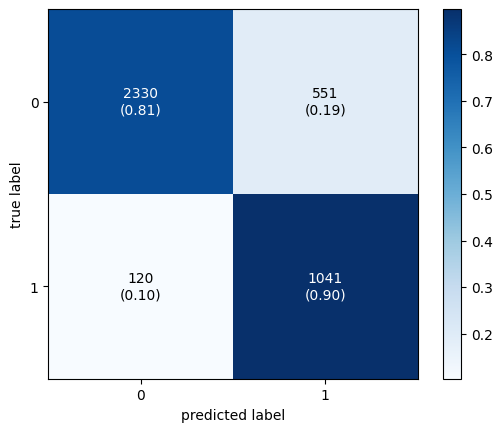

In [ ]:
knn.fit(X_undersam, y_undersam)
y_pred_knn_under = rf.predict(X_val_scaler)
print(classification_report(y_val, y_pred_knn_under))
cm1 = confusion_matrix(y_val,y_pred_knn_under)
plot_confusion_matrix(conf_mat=cm1,show_absolute=True,
                                show_normed=True,
                                colorbar=True,
                                )
plt.show()

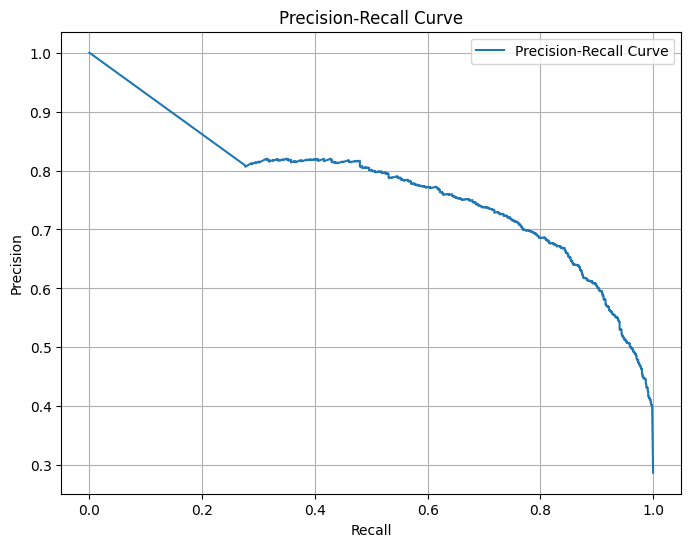

In [ ]:
y_scores = knn.predict_proba(X_val_scaler)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_scores)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

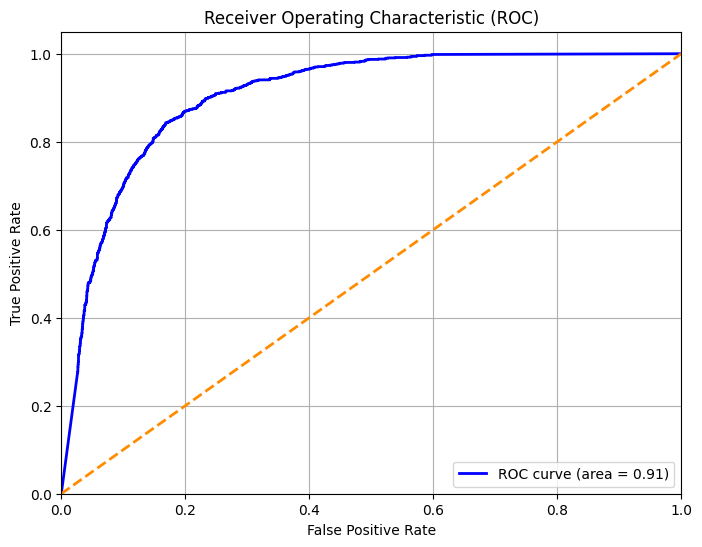

In [ ]:
fpr, tpr, thresholds = roc_curve(y_val, y_scores)

auc_score = roc_auc_score(y_val, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % auc_score)
plt.plot([0, 1], [0, 1], color='darkorange', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

              precision    recall  f1-score   support

         0.0       0.93      0.84      0.89      2881
         1.0       0.69      0.85      0.76      1161

    accuracy                           0.85      4042
   macro avg       0.81      0.85      0.82      4042
weighted avg       0.86      0.85      0.85      4042



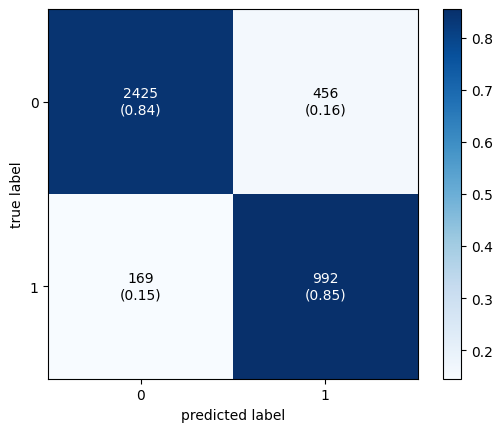

In [ ]:
knn.fit(X_oversam, y_oversam)
y_pred_knn_over = rf.predict(X_val_scaler)
print(classification_report(y_val, y_pred_knn_over))
cm1 = confusion_matrix(y_val,y_pred_knn_over)
plot_confusion_matrix(conf_mat=cm1,show_absolute=True,
                                show_normed=True,
                                colorbar=True,
                                )
plt.show()

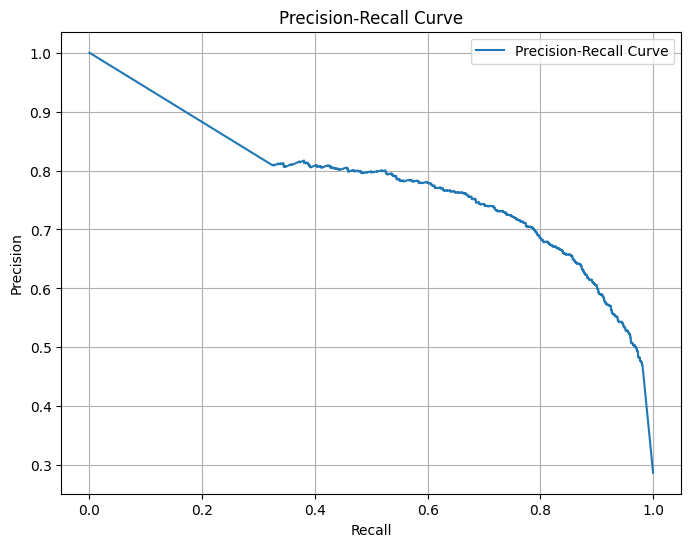

In [ ]:
y_scores = knn.predict_proba(X_val_scaler)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_scores)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

              precision    recall  f1-score   support

         0.0       0.93      0.84      0.89      2881
         1.0       0.69      0.85      0.76      1161

    accuracy                           0.85      4042
   macro avg       0.81      0.85      0.82      4042
weighted avg       0.86      0.85      0.85      4042



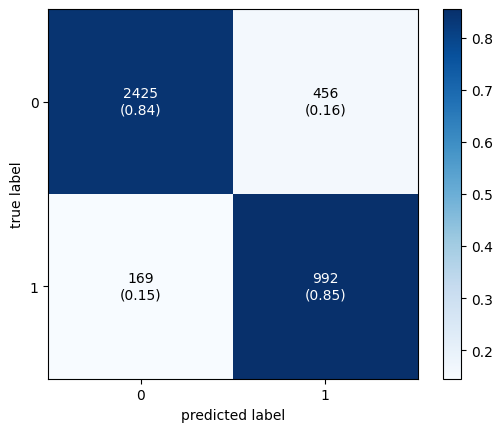

In [ ]:
knn.fit(X_smote, y_smote)
y_pred_knn_smote = rf.predict(X_val_scaler)
print(classification_report(y_val, y_pred_knn_smote))
cm1 = confusion_matrix(y_val,y_pred_knn_smote)
plot_confusion_matrix(conf_mat=cm1,show_absolute=True,
                                show_normed=True,
                                colorbar=True,
                                )
plt.show()

In [ ]:
# Load the val.csv
val = pd.read_csv("test.csv")

# Assign X val and y val
X_test = val.drop('FraudFound_P', axis=1)
y_test = val['FraudFound_P']

#Display the shape of X_train.
X_test.shape

(4041, 17)

In [ ]:
X_test_scaler = Scaler_x.transform(X_test)

In [ ]:
rf.fit(X_undersam,y_undersam)

RandomForestClassifier(max_depth=20, min_samples_split=5, n_estimators=200)

              precision    recall  f1-score   support

         0.0       0.96      0.80      0.87      2911
         1.0       0.64      0.91      0.75      1130

    accuracy                           0.83      4041
   macro avg       0.80      0.85      0.81      4041
weighted avg       0.87      0.83      0.84      4041



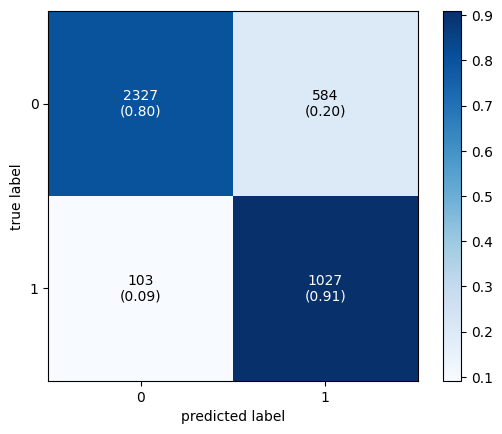

In [ ]:
y_pred_rf_under_test = rf.predict(X_test_scaler)
print(classification_report(y_test, y_pred_rf_under_test))
cm1 = confusion_matrix(y_test,y_pred_rf_under_test)
plot_confusion_matrix(conf_mat=cm1,show_absolute=True,
                                show_normed=True,
                                colorbar=True,
                                )
plt.show()

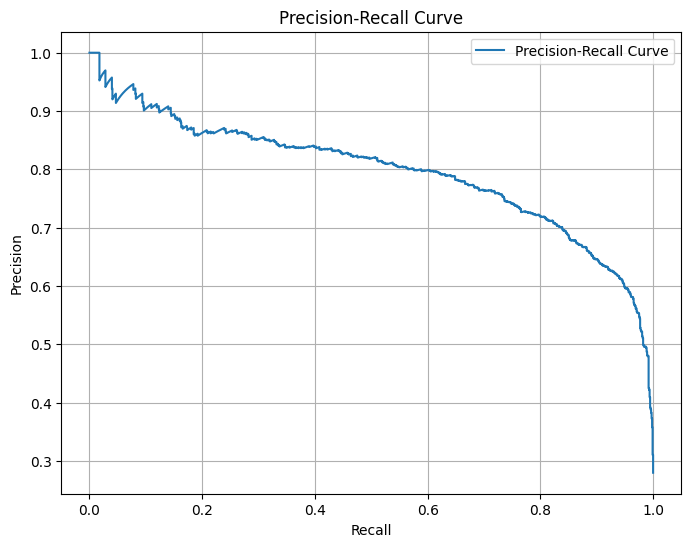

In [ ]:
y_scores = rf.predict_proba(X_test_scaler)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

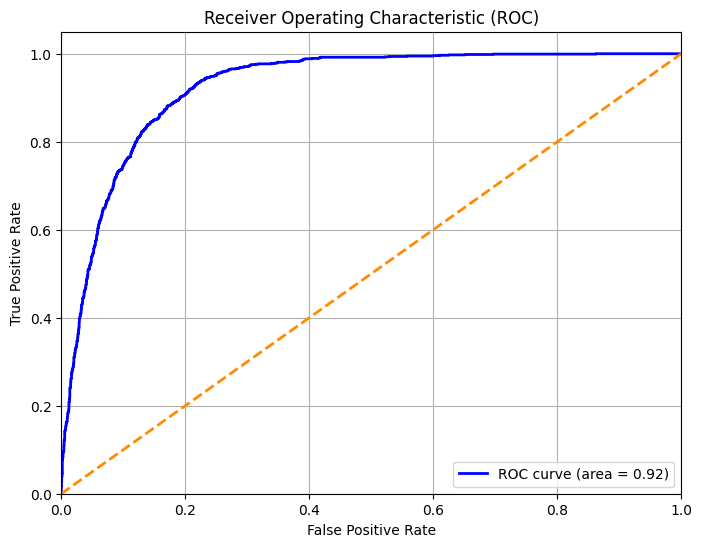

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

auc_score = roc_auc_score(y_test, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % auc_score)
plt.plot([0, 1], [0, 1], color='darkorange', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
